# Multi-Linear Regression Model for Forecasting Marketing Performance.ipynb

In [ ]:
# importing dependencies
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score,roc_curve,auc
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# read file
# data = pd.read_csv('./Data/marketing_campaign_dataset.csv')
# print("Data loaded successfully")

from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/Dataset/marketing_campaign_dataset.csv"
data = pd.read_csv(path)

Mounted at /content/drive


In [ ]:
# CAUTION RUN THIS ONLY IN JUPYTER NOTEBOOK
# read from csv dd into database

# importing dependencies
import pandas as pd
import mysql.connector

# read file
data = pd.read_csv('./Data/marketing_campaign_dataset.csv')
print("Data loaded successfully")

# setting up database connection
import mysql.connector

mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password="Piper@1202"
)

mycursor = mydb.cursor()

# mycursor.execute("CREATE DATABASE roi_prediction_db")
print("Database created successfully")

# Creating table
mycursor.execute("USE roi_prediction_db")
# mycursor.execute("CREATE TABLE marketing_campaign ( Campaign_ID INT PRIMARY KEY, Company VARCHAR(100), Campaign_Type VARCHAR(50), Target_Audience VARCHAR(50), Duration VARCHAR(20), Channel_Used VARCHAR(50), Conversion_Rate FLOAT, Acquisition_Cost DECIMAL(15,2), ROI FLOAT, Location VARCHAR(100), Language VARCHAR(50), Clicks INT, Impressions INT, Engagement_Score INT, Customer_Segment VARCHAR(100), Date DATE);")
# print("Table created successfully")

# INSERT QUERY
insert_query = """
INSERT INTO marketing_campaign (
    Campaign_ID, Company, Campaign_Type, Target_Audience, Duration,
    Channel_Used, Conversion_Rate, Acquisition_Cost, ROI,
    Location, Language, Clicks, Impressions, Engagement_Score,
    Customer_Segment, Date
) VALUES (
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s
)
"""

# Clean Acquisition_Cost: remove $ and commas, convert to float
data["Acquisition_Cost"] = ( data["Acquisition_Cost"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float))

# Convert Date to YYYY-MM-DD (MySQL friendly)
data["Date"] = pd.to_datetime(data["Date"], format="%d-%m-%Y").dt.date

# INSERT ROWS

for _, row in data.iterrows():
    mycursor.execute(insert_query, (
        int(row["Campaign_ID"]),
        row["Company"],
        row["Campaign_Type"],
        row["Target_Audience"],
        row["Duration"],
        row["Channel_Used"],
        float(row["Conversion_Rate"]),
        float(row["Acquisition_Cost"]),
        float(row["ROI"]),
        row["Location"],
        row["Language"],
        int(row["Clicks"]),
        int(row["Impressions"]),
        int(row["Engagement_Score"]),
        row["Customer_Segment"],
        row["Date"]
    ))
    print(f"Inserted Campaign_ID: {row['Campaign_ID']}")

mydb.commit()
print("All rows inserted successfully!")

mycursor.close()
mydb.close()


In [ ]:
sql_query = "SELECT * FROM marketing_campaign;"

# read from database
df = pd.read_sql(sql_query, con=mydb)
print(df.head())

In [ ]:
data.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,01-01-2021
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,02-01-2021
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,03-01-2021
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,04-01-2021
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,05-01-2021


In [ ]:
print("\nData Describe : \n")
data.describe()


Data Describe : 



,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [ ]:
print("\nData Information")
data.info()


Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  object 
 2   Campaign_Type     200000 non-null  object 
 3   Target_Audience   200000 non-null  object 
 4   Duration          200000 non-null  object 
 5   Channel_Used      200000 non-null  object 
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  object 
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  object 
 10  Language          200000 non-null  object 
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  object 
 15  Date              200000 non-null  object 
dtypes:

In [ ]:
# Data Shape
print("\nData Shape (rows,columns) : ",data.shape)


Data Shape (rows,columns) :  (200000, 16)


In [ ]:
# Columns
# print("\nColumns : ",data.columns.values)

# Column Dtypes
print("\nD-types of object : \n",data.dtypes)


D-types of object : 
 Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
dtype: object


In [ ]:
# Checking Duplicates
print("\nTotal Duplicated rows",data.duplicated().sum())
# no duplicates


Total Duplicated rows 0


In [ ]:
# Checking Null
print("\nTotal Null Values \n",data.isnull().sum())
# no  null values


Total Null Values 
 Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64


In [ ]:
# row information target and feature
def get_unique(col_name, data):
		print("\nTotal unique values of "+col_name +" column : ",data[col_name].nunique())
		print("\nUnique values : ",data[col_name].unique())

In [ ]:
for column in ['Company','Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Location', 'Language', 'Customer_Segment']:get_unique(column, data)



Total unique values of Company column :  5

Unique values :  ['Innovate Industries' 'NexGen Systems' 'Alpha Innovations'
 'DataTech Solutions' 'TechCorp']

Total unique values of Campaign_Type column :  5

Unique values :  ['Email' 'Influencer' 'Display' 'Search' 'Social Media']

Total unique values of Target_Audience column :  5

Unique values :  ['Men 18-24' 'Women 35-44' 'Men 25-34' 'All Ages' 'Women 25-34']

Total unique values of Duration column :  4

Unique values :  ['30 days' '60 days' '15 days' '45 days']

Total unique values of Channel_Used column :  6

Unique values :  ['Google Ads' 'YouTube' 'Instagram' 'Website' 'Facebook' 'Email']

Total unique values of Location column :  5

Unique values :  ['Chicago' 'New York' 'Los Angeles' 'Miami' 'Houston']

Total unique values of Language column :  5

Unique values :  ['Spanish' 'German' 'French' 'Mandarin' 'English']

Total unique values of Customer_Segment column :  5

Unique values :  ['Health & Wellness' 'Fashionistas' 'Outdoo

In [ ]:
# No of unique categories
company_values = data['Company'].value_counts()
print("Total unique categories of Company column:\n", company_values)

Total unique categories of Company column:
 Company
TechCorp               40237
Alpha Innovations      40051
DataTech Solutions     40012
NexGen Systems         39991
Innovate Industries    39709
Name: count, dtype: int64


## Data Visaliation (Understanding of Data)

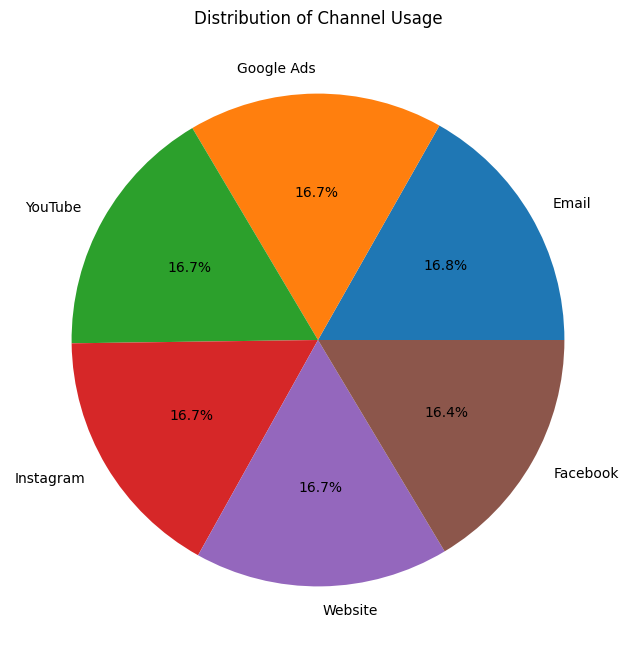

In [ ]:
# Count the occurrences of each channel used
channel_counts = data['Channel_Used'].value_counts()

# Create a pie chart to visualize the distribution of channel usage
plt.figure(figsize=(8, 8))
plt.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%')
plt.title('Distribution of Channel Usage')
plt.show()

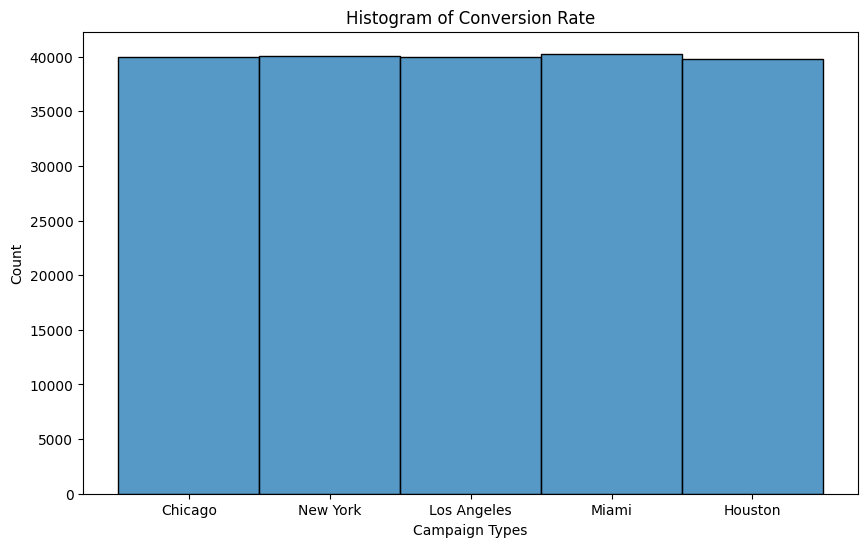

In [ ]:
# Histogram of Conversion Rate
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Location')
plt.title('Histogram of Conversion Rate')
plt.xlabel('Campaign Types')
plt.ylabel('Count')
plt.show()

<!-- ## Cleaning and Pre processing Data -->

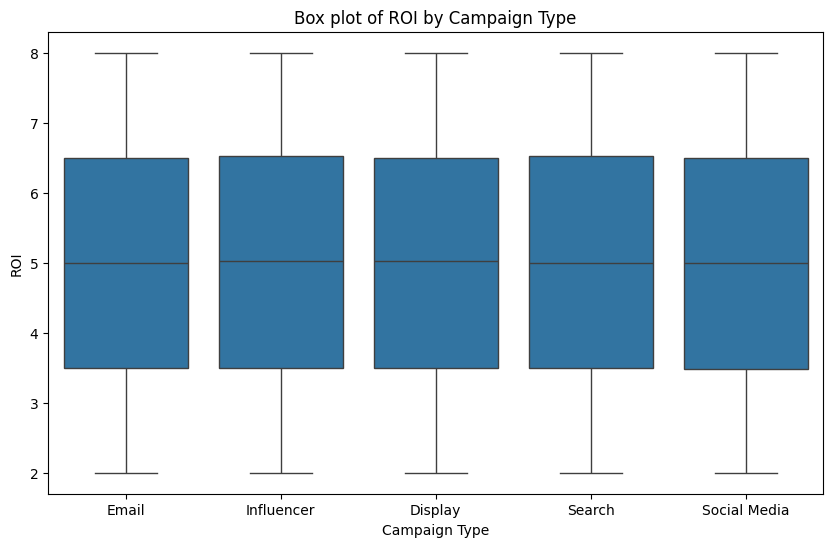

In [ ]:
# Box plot of ROI by Campaign Type
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Campaign_Type', y='ROI')
plt.title('Box plot of ROI by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('ROI')
plt.show()

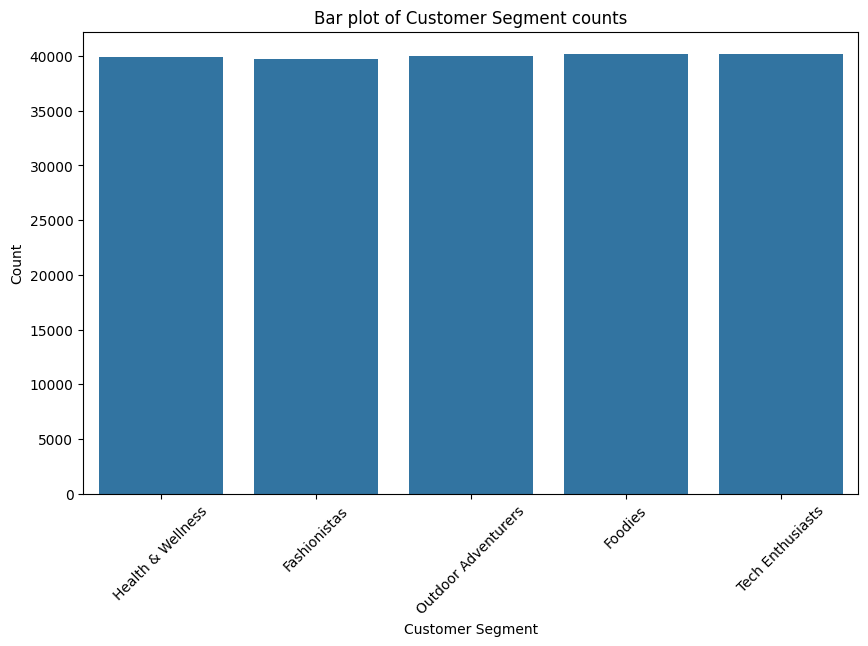

In [ ]:
# Bar plot of Customer Segment counts
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Customer_Segment')
plt.title('Bar plot of Customer Segment counts')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

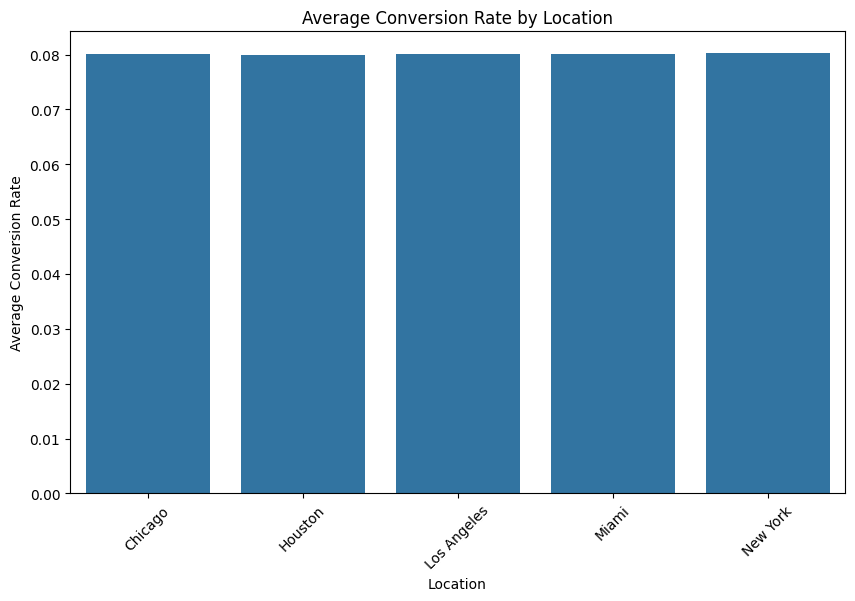

In [ ]:
# Group data by location and calculate the average conversion rate
location_conversion = data.groupby('Location')['Conversion_Rate'].mean().reset_index()

# Create a map plot using the average conversion rate
plt.figure(figsize=(10, 6))
sns.barplot(data=location_conversion, x='Location', y='Conversion_Rate')
plt.title('Average Conversion Rate by Location')
plt.xlabel('Location')
plt.ylabel('Average Conversion Rate')
plt.xticks(rotation=45)
plt.show()

<Figure size 1000x600 with 0 Axes>

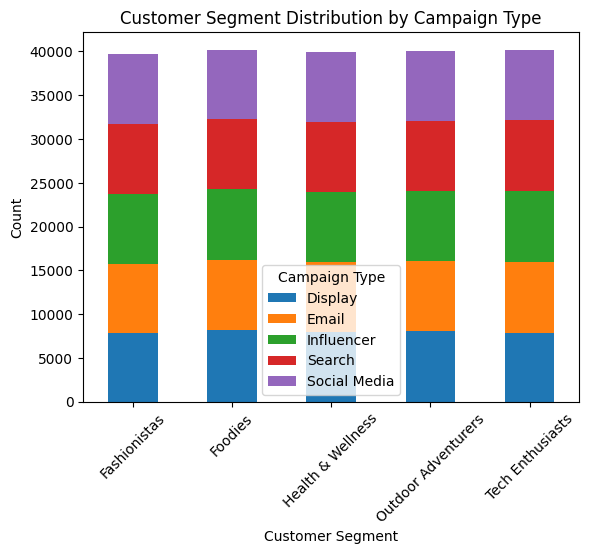

In [ ]:
# Customer Segment Distribution - Stacked Bar Chart Visualization

# Create a cross-tabulation of customer segments and campaign types
segment_campaign = pd.crosstab(data['Customer_Segment'], data['Campaign_Type'])

# Create a stacked bar chart to visualize the distribution of customer segments across campaign types
plt.figure(figsize=(10, 6))
segment_campaign.plot(kind='bar', stacked=True)
plt.title('Customer Segment Distribution by Campaign Type')
plt.xlabel('Customer Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Campaign Type')
plt.show()

In [ ]:
# dropping Campaign_ID column
# doesnt contribute to the pred. ROI Rate
# data.drop(columns=['Campaign_ID'],inplace=True)
# temp droping date column
data.drop(columns=['Date'],inplace=True)

In [ ]:
# WORKING WITH DATE
# Convert 'Date' column to datetime format
# data['Date'] = pd.to_datetime(data['Date'])

### Analysing and working with numerical data


In [ ]:
# Duration Column
# it basically states 15 days 30 days.
# removing days from values
# Unique values :  '30 days' '60 days' '15 days' '45 days'

# Clean Duration column
data['Duration'] = data['Duration'].str.extract(r'(\d+)').astype(int)
print(data['Duration'].head())
# print(type(data['Duration'][0]))

0    30
1    60
2    30
3    60
4    15
Name: Duration, dtype: int64


In [ ]:
# Conversion_Rate Column
# Conversion Rate measures how many people took the desired action out of all people who saw your campaign
# Conversion Rate = (Number of Conversions / Total Impressions) × 100 Our is in decimals
# no change in data needed

# Acquisition_Cost
# $ dollar and , comma sign should beremoved and sting should be converted to floot
data['Acquisition_Cost'] = data['Acquisition_Cost'].replace('[\$,]', '', regex=True)
data['Acquisition_Cost'] = data['Acquisition_Cost'].astype(float)
data['Acquisition_Cost']


<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1450695105.py:8: SyntaxWarning: invalid escape sequence '\$'
  data['Acquisition_Cost'] = data['Acquisition_Cost'].replace('[\$,]', '', regex=True)


,Acquisition_Cost
0,16174.0
1,11566.0
2,10200.0
3,12724.0
4,16452.0
...,...
199995,18365.0
199996,8168.0
199997,13397.0
199998,18508.0


In [ ]:
# ROI -- target column
# Min-Max scaling to 0-100 (this can be skipped as well but needed to improve performance)
# data['ROI'] = (data['ROI'] - data['ROI'].min()) / (data['ROI'].max() - data['ROI'].min()) * 100

In [ ]:
data['ROI']

,ROI
0,6.29
1,5.61
2,7.18
3,5.55
4,6.50
...,...
199995,2.84
199996,4.14
199997,3.25
199998,3.86


In [ ]:
# Impressions and click column
# Impressions = how many people saw your ad.
# Clicks = how many people clicked the ad.
# If impressions are very high but ROI is low → campaign is inefficient
# If impressions are low but ROI is high → highly targeted campaign

# More clicks → more conversions → better ROI
# Low clicks → low engagement → low ROI

# Individully won't give too output just ordinary
# cant be removed because without them model looses understanding ofcampaign size and engagemnet
# But when these includes CPR CPC AND CPM Model understands better

# CTR = Clicks / Impressions Click Through Rate -- Shows engagement quality
# CPC = Acquisition_Cost / Clicks Cost Per Click  -- Shows cost efficiency
# CPM = (Acquisition_Cost / Impressions) * 1000 Cost Per Mille (CPM) -- Shows cost per 1000 impressions

# Impressions = “How many people saw my ad?”
# Clicks = “How many people were interested?”
# Conversion Rate = “How many people actually took action?”
# ROI = “Was it worth the money?”

# Your regression model needs all four to understand the whole funnel.
# Regression understands ratios much more clearly than raw traffic volume


In [ ]:
# Safe division function (prevents divide-by-zero errors)
def safe_divide(a, b):
    return np.where(b == 0, 0, a / b)

### Create derived metrics

In [ ]:
# CTR (Click Through Rate)
data['CTR'] = safe_divide(data['Clicks'], data['Impressions'])

In [ ]:
# CPC (Cost Per Click)
data['CPC'] = safe_divide(data['Acquisition_Cost'], data['Clicks'])

In [ ]:
# CPM (Cost Per 1000 Impressions)
data['CPM'] = safe_divide(data['Acquisition_Cost'], data['Impressions']) * 1000

In [ ]:
# Conversion Rate (Conversions / Clicks)
# data['Conversion_Rate'] = safe_divide(data['Conversion_Rate'], data['Clicks'])
# we already have

In [ ]:
# CPA (Cost Per Acquisition / Cost Per Conversion)
data['CPA'] = safe_divide(data['Acquisition_Cost'], data['Conversion_Rate'])

In [ ]:
data[['Clicks', 'Impressions', 'CTR', 'CPC', 'CPM', 'Conversion_Rate', 'CPA']].head()

,Clicks,Impressions,CTR,CPC,CPM,Conversion_Rate,CPA
0,506,1922,0.263267,31.964427,8415.192508,0.04,404350.000000
1,116,7523,0.015419,99.706897,1537.418583,0.12,96383.333333
2,584,7698,0.075864,17.465753,1325.019486,0.07,145714.285714
3,217,1820,0.119231,58.635945,6991.208791,0.11,115672.727273
4,379,4201,0.090217,43.408971,3916.210426,0.05,329040.000000


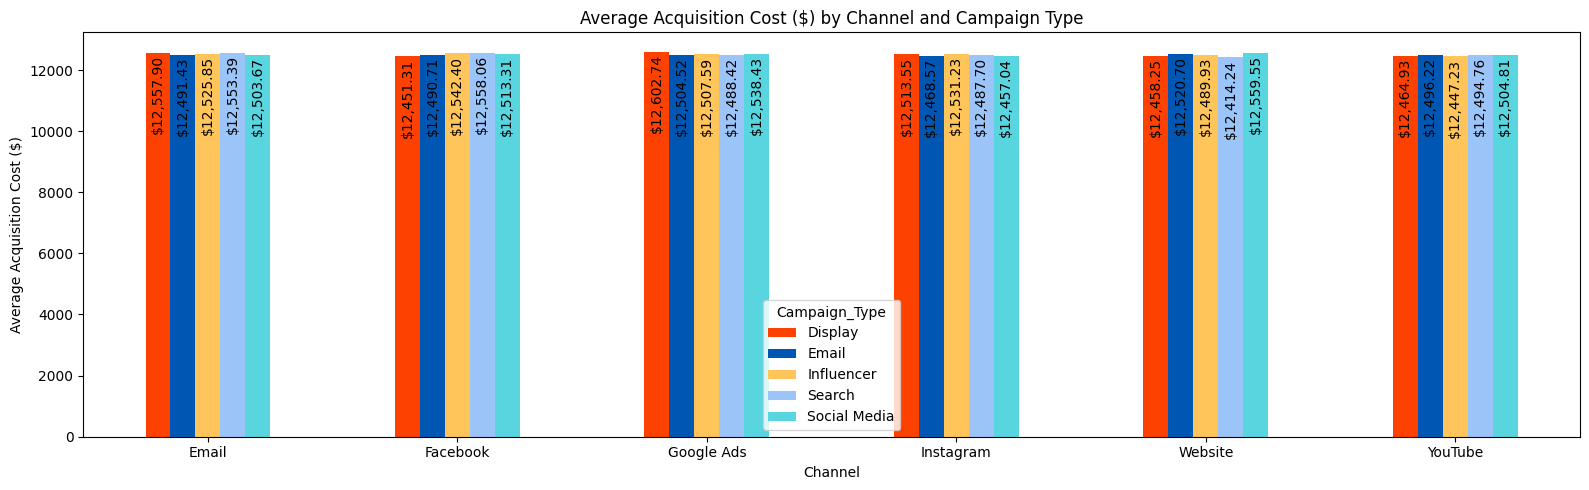

In [ ]:
# Average Acquisition Cost across different Channel and Campaign Type
avg_acquisition_cost_by_channel_and_campaign_type = data.groupby(['Channel_Used', 'Campaign_Type'])['Acquisition_Cost'].mean().unstack()
colors = ['#FC4100', '#0056B3', '#FFC55A', '#9BC4F8', '#59D5E0', '#FB773C']

# Plot data as a bar chart
bars = avg_acquisition_cost_by_channel_and_campaign_type.plot(kind='bar', color=colors, figsize=(16, 5))

# Add title and labels
plt.title('Average Acquisition Cost ($) by Channel and Campaign Type')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.ylabel('Average Acquisition Cost ($)')

# Add data labels on top of each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'${height:,.2f}',
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center',
                  va='center',
                  xytext=(0, -30),
                  textcoords='offset points',
                  rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

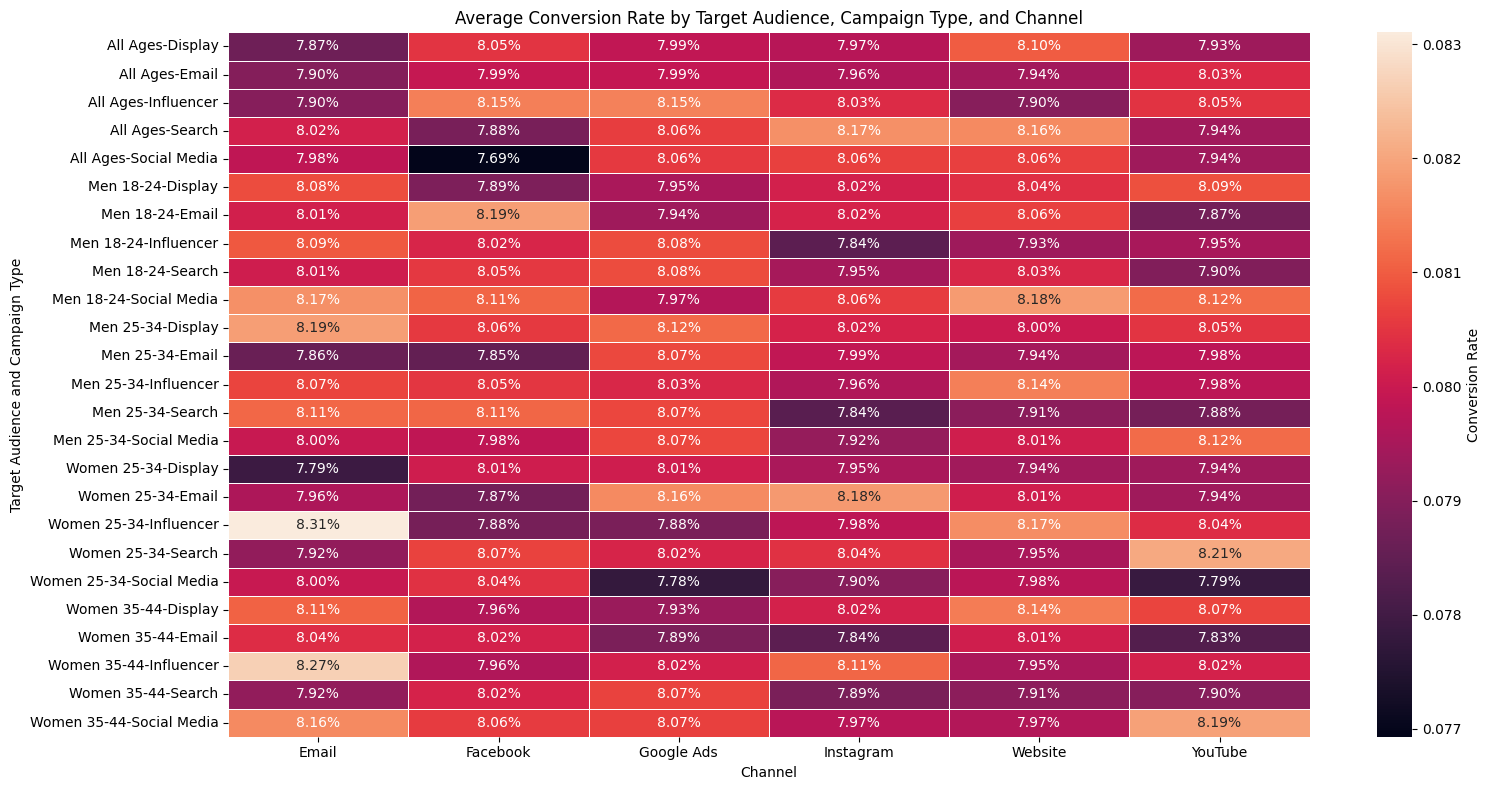

In [ ]:
# Average Conversion Rate by Target Audience, Campaign Type, and Channel
avg_conversion_rate_by_3_fields = data.groupby(['Target_Audience', 'Campaign_Type', 'Channel_Used'])['Conversion_Rate'].mean().unstack()

# Plot data as a heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(avg_conversion_rate_by_3_fields, annot=True, fmt='.2%', linewidths=0.5, cbar_kws={'label': 'Conversion Rate'})

# Add title and labels
plt.title('Average Conversion Rate by Target Audience, Campaign Type, and Channel')
plt.xlabel('Channel')
plt.xticks(rotation=0)
plt.ylabel('Target Audience and Campaign Type')

# Show plot
plt.tight_layout()
plt.show()

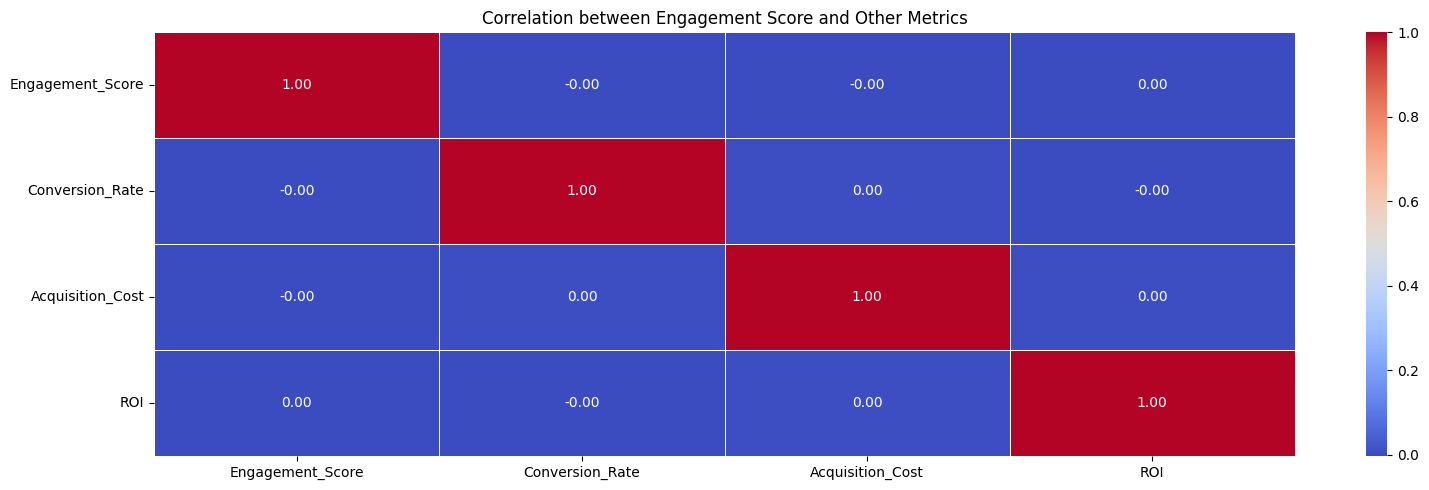

In [ ]:
# Select the relevant columns for correlation analysis
metrics = data[['Engagement_Score', 'Conversion_Rate', 'Acquisition_Cost', 'ROI']]

# Calculate the correlation matrix
correlation_matrix = metrics.corr()

# Plot the heatmap to visualize correlations
plt.figure(figsize=(16, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation between Engagement Score and Other Metrics')
plt.xticks(rotation=0)

# Show the plot
plt.tight_layout()
plt.show()
# 0 coorelation

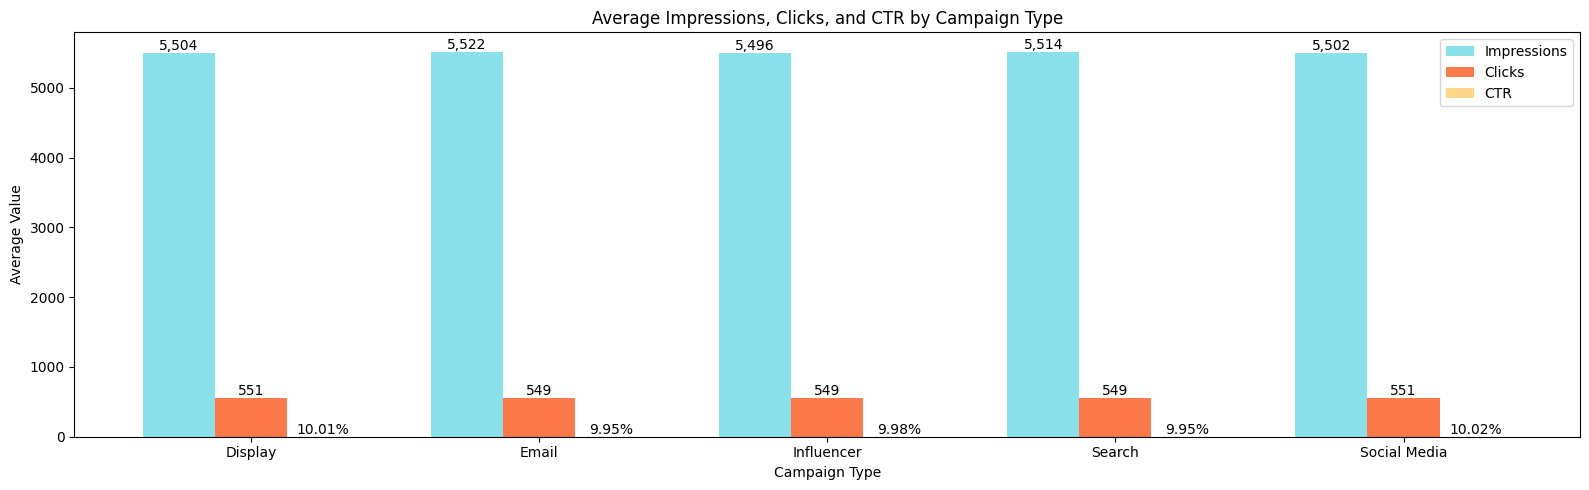

In [ ]:
# Average number of Impressions
avg_number_of_impressions = data.groupby(['Campaign_Type']).Impressions.mean()

# Average number of Clicks
avg_number_of_clicks = data.groupby(['Campaign_Type']).Clicks.mean()

# Average Click-Through Rate (CTR)
avg_ctr = avg_number_of_clicks / avg_number_of_impressions

bar_width = 0.25
index = range(len(avg_number_of_impressions))

# Plot bars for Impressions, Clicks, and CTR
plt.figure(figsize=(16, 5))
bars1 = plt.bar(index, avg_number_of_impressions, bar_width, label='Impressions', color='#59D5E0', alpha=0.7)
bars2 = plt.bar([i + bar_width for i in index], avg_number_of_clicks, bar_width, label='Clicks', color='#FC4100', alpha=0.7)
bars3 = plt.bar([i + 2 * bar_width for i in index], avg_ctr, bar_width, label='CTR', color='#FFC55A', alpha=0.7)

# Add title and labels
plt.title('Average Impressions, Clicks, and CTR by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Average Value')
plt.xticks([i + bar_width for i in index], avg_number_of_impressions.index, rotation=0)

# Add data labels with condition
def add_labels(bars, is_ctr=False):
    for bar in bars:
        height = bar.get_height()
        label = f'{height:.2%}'
        if not is_ctr:
            label = f'{height:,.0f}'
        plt.text(bar.get_x() + bar.get_width() / 2, height, label, ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3, is_ctr=True)

# Disable grid
plt.grid(False)

# Legend
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# # Convert into a correct datatype
# data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d')

# # Extract year and month for temporal analysis
# data['Year'] = data['Date'].dt.year
# data['Month'] = data['Date'].dt.month

# # Aggregate data by month to analyze campaign performance over time
# campaign_monthly_performance = data.groupby(['Year', 'Month']).agg({
#     'Engagement_Score': 'mean',
#     'Conversion_Rate': 'mean',
#     'ROI': 'mean'
# }).reset_index()

In [ ]:
# # Lineplot for Average Engagement Score
# plt.figure(figsize=(16, 5))
# lineplot = sns.lineplot(x='Month', y='Engagement_Score', hue='Year', data=campaign_monthly_performance, marker='o')

# # Adding data labels to each point
# for line in lineplot.lines:
#     for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
#         plt.text(x_data,
#                  y_data,
#                  f'{y_data:.2f}',
#                  ha='center',
#                  va='bottom',
#                  color='#0056B3')

# # Add title and labels
# plt.title('Campaign Performance Over Time - Average Engagement Score by Monthly')
# plt.xlabel('Months')
# plt.ylabel('Average Engagement Score')

# # Show month names on x-axis
# plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# # Disable grid
# plt.grid(False)

# # Show the plot
# plt.tight_layout()
# plt.show()

### Working with categorical Values

---



In [ ]:
# Engagement_Score
# It shows values at the scale of 1 to 10
# no change needed

In [ ]:
# Working with categorical columns
# data encoding function common
def encoding(column_list):
    for column_name in column_list:
        label_encoder = LabelEncoder()
        data[column_name] = label_encoder.fit_transform(data[column_name])

In [ ]:
# Encoding each categorical column (model needs numericals)
encoding(column_list=['Company','Campaign_Type','Target_Audience', 'Channel_Used','Location','Language','Customer_Segment'])
data[['Company','Campaign_Type','Target_Audience', 'Channel_Used','Location','Language','Customer_Segment']].head()

,Company,Campaign_Type,Target_Audience,Channel_Used,Location,Language,Customer_Segment
0,2,1,1,2,0,4,2
1,3,1,4,2,4,2,0
2,0,2,2,5,2,1,3
3,1,0,0,5,3,3,2
4,3,1,2,5,2,3,2


In [ ]:
# TEMPPP
# data.drop(columns=['Company','Campaign_Type','Target_Audience', 'Channel_Used','Location','Language','Customer_Segment'],inplace=True)
# data.drop(columns=['Duration','Clicks','Impressions','Engagement_Score'],inplace=True)

In [ ]:
# data
data.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,CTR,CPC,CPM,CPA
0,1,2,1,1,30,2,0.04,16174.0,6.29,0,4,506,1922,6,2,0.263267,31.964427,8415.192508,404350.000000
1,2,3,1,4,60,2,0.12,11566.0,5.61,4,2,116,7523,7,0,0.015419,99.706897,1537.418583,96383.333333
2,3,0,2,2,30,5,0.07,10200.0,7.18,2,1,584,7698,1,3,0.075864,17.465753,1325.019486,145714.285714
3,4,1,0,0,60,5,0.11,12724.0,5.55,3,3,217,1820,7,2,0.119231,58.635945,6991.208791,115672.727273
4,5,3,1,2,15,5,0.05,16452.0,6.50,2,3,379,4201,3,2,0.090217,43.408971,3916.210426,329040.000000


In [ ]:
print(data.columns.values)

['Campaign_ID' 'Company' 'Campaign_Type' 'Target_Audience' 'Duration'
 'Channel_Used' 'Conversion_Rate' 'Acquisition_Cost' 'ROI' 'Location'
 'Language' 'Clicks' 'Impressions' 'Engagement_Score' 'Customer_Segment'
 'CTR' 'CPC' 'CPM' 'CPA']


In [ ]:
# CAUTION RUN THIS ONLY IN JUPYTER NOTEBOOK
# read from csv dd into database

# setting up database connection
mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password="Piper@1202"
)

mycursor = mydb.cursor()

# mycursor.execute("CREATE DATABASE roi_cleaned_db")
print("Database created successfully")

# Creating table
mycursor.execute("USE roi_prediction_db")
# mycursor.execute("CREATE TABLE marketing_campaign_cleaned ( Campaign_ID INT PRIMARY KEY, Company VARCHAR(100), Campaign_Type VARCHAR(50), Target_Audience VARCHAR(50), Duration VARCHAR(20), Channel_Used VARCHAR(50), Conversion_Rate FLOAT, Acquisition_Cost DECIMAL(15,2), ROI FLOAT, Location VARCHAR(100), Language VARCHAR(50), Clicks INT, Impressions INT, Engagement_Score INT, Customer_Segment VARCHAR(100), Date DATE);")
# print("Table created successfully")

# INSERT QUERY
insert_query = """
INSERT INTO marketing_campaign_cleaned (
    Campaign_ID, Company, Campaign_Type, Target_Audience, Duration,
    Channel_Used, Conversion_Rate, Acquisition_Cost, ROI, Location,
    Language, Clicks, Impressions, Engagement_Score, Customer_Segment,
    Date, CTR, CPC, CPM, CPA
) VALUES (
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s
)
"""

# INSERT ROWS

for _, row in df.iterrows():
  mycursor.execute(insert_query, (
        int(row["Campaign_ID"]),
        row["Company"],
        row["Campaign_Type"],
        row["Target_Audience"],
        row["Duration"],
        row["Channel_Used"],
        float(row["Conversion_Rate"]),
        float(row["Acquisition_Cost"]),
        float(row["ROI"]),
        row["Location"],
        row["Language"],
        int(row["Clicks"]),
        int(row["Impressions"]),
        int(row["Engagement_Score"]),
        row["Customer_Segment"],
        row["Date"],
        float(row["CTR"]),
        float(row["CPC"]),
        float(row["CPM"]),
        float(row["CPA"])
    ))
  print(f"Inserted Campaign_ID: {row['Campaign_ID']}")

mydb.commit()
print("All rows inserted successfully!")

mycursor.close()
mydb.close()

In [ ]:
sql_query = "SELECT * FROM marketing_campaign_cleaned;"

# read from database
df = pd.read_sql(sql_query, con=mydb)
print(df.head())

In [ ]:
# Log transform target
data["ROI_log"] = np.log1p(data["ROI"])

# Log transform skewed features
skew_cols = ["Clicks","Impressions","Acquisition_Cost","CTR","CPC","CPM","CPA"]
for col in skew_cols:
    data[col+"_log"] = np.log1p(data[col])

# final feature set
num_cols = [c+"_log" for c in skew_cols] + ["Conversion_Rate"]
cat_cols = ["Company","Campaign_Type","Target_Audience","Channel_Used",
            "Location","Language","Customer_Segment"]

In [ ]:
# data splitting
x = data.drop(columns=['ROI'],inplace=False).iloc[:,:]
y = data.iloc[:,8]

In [ ]:
# x.head()
# y.head()

In [ ]:
# train test split
x_train, x_test, y_train,y_test = train_test_split(x,y,random_state=1,test_size=0.20)

In [ ]:
# x_train.shape
# y_train.shape

In [ ]:
# Training the model
print("TRAINING THE MODEL USING Liner Regression")
lr = LinearRegression()
lr.fit(x_train,y_train)

TRAINING THE MODEL USING Liner Regression


LinearRegression()

In [ ]:
# predicting the value of x_test
y_predicted = lr.predict(x_test)

In [ ]:
y_test

,ROI
49673,7.05
171551,3.27
5506,5.08
38370,7.25
36930,3.76
...,...
63840,2.51
128107,7.92
108940,4.95
199933,6.29


In [ ]:
y_predicted

array([6.88976186, 3.35458778, 5.32336641, ..., 5.20990196, 6.33346688,
       2.06402385])

In [ ]:
# model evaluation
print('mean_squared_error : ', mean_squared_error(y_test, y_predicted))
print('mean_absolute_error : ', mean_absolute_error(y_test, y_predicted))
print('R2 score : ', r2_score(data.loc[y_test.index, "ROI"], y_predicted))

mean_squared_error :  0.057718832608880964
mean_absolute_error :  0.2065104613174211
R2 score :  0.9808326028773254


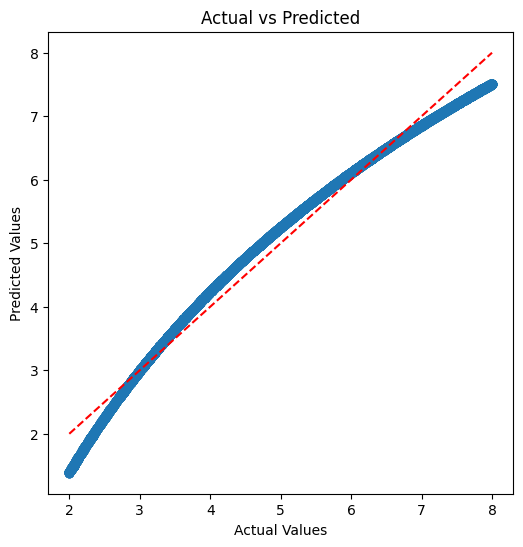

In [ ]:
import matplotlib.pyplot as plt

# Figure to show actual and predicted values
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_predicted, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45-degree line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.show()

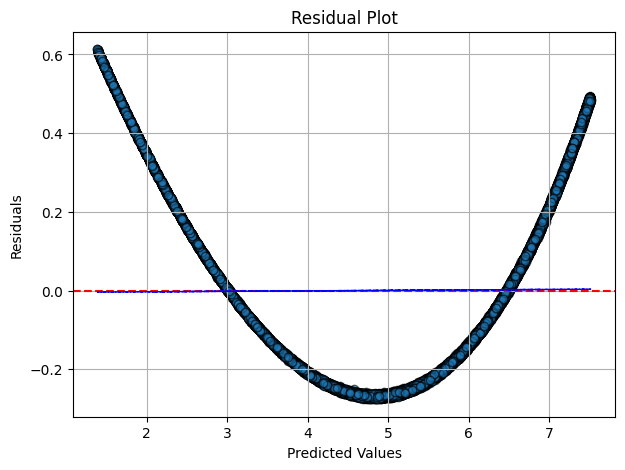

In [ ]:
# Resedual graph
# Ensure y_test and y_predicted are numpy arrays
y_test = np.array(y_test)
y_predicted = np.array(y_predicted)

# Calculate residuals
residuals = y_test - y_predicted

# Residual plot
plt.figure(figsize=(7,5))
plt.scatter(y_predicted, residuals, alpha=0.6, edgecolor='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)  # zero error line
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True)

# Optional: add a trend line to check for patterns
z = np.polyfit(y_predicted, residuals, 1)
p = np.poly1d(z)
plt.plot(y_predicted, p(y_predicted), "b--", linewidth=1)

plt.show()

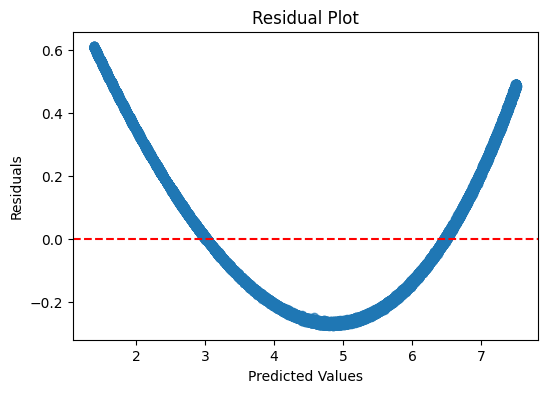

In [ ]:
# Resedual graph
residuals = y_test - y_predicted

plt.figure(figsize=(6,4))
plt.scatter(y_predicted, residuals, alpha=0.7)
plt.axhline(0, color='r', linestyle='--')  # zero error line
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [ ]:
# JUST FOR CHECKING
# Suppose y_test and y_pred are pandas Series or numpy arrays
# results_df = pd.DataFrame({'Actual Value': y_test,'Predicted Value':y_predicted, 'Difference':y_test - y_predicted})

# Save to CSV
# results_df.to_csv('predictions4.csv', index=False)

# print("Saved y_test and y_predicted to predictions.csv")